# Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Load Data

In [2]:
def load_data(real_path="real.txt", fake_path="fake.txt", test_size=0.3, random_state=42):
    # Read headlines
    with open(real_path, "r", encoding="utf-8") as f:
        real_headlines = [line.strip() for line in f if line.strip()]
    
    with open(fake_path, "r", encoding="utf-8") as f:
        fake_headlines = [line.strip() for line in f if line.strip()]
    
    # Combine text and labels
    headlines = real_headlines + fake_headlines
    labels = [1] * len(real_headlines) + [0] * len(fake_headlines)   # 1 = real, 0 = fake
    
    # Vectorize headlines
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(headlines)
    y = np.array(labels)
    
    # Split into training and test sets
    X_train, X_test, y_train, y_test, train_texts, test_texts = train_test_split(
        X, y, headlines, test_size=test_size, random_state=random_state, stratify=y
    )
    
    return X_train, X_test, y_train, y_test, vectorizer, train_texts, test_texts

# Load Dataset

In [3]:
X_train, X_test, y_train, y_test, vectorizer, train_texts, test_texts = load_data()

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Number of real headlines in training:", np.sum(y_train == 1))
print("Number of fake headlines in training:", np.sum(y_train == 0))
print("Number of real headlines in test:", np.sum(y_test == 1))
print("Number of fake headlines in test:", np.sum(y_test == 0))

Training set shape: (2286, 5799)
Test set shape: (980, 5799)
Number of real headlines in training: 1377
Number of fake headlines in training: 909
Number of real headlines in test: 591
Number of fake headlines in test: 389


The dataset was split into 70% training (2286 headlines) and 30% testing (980 headlines).
The class distribution is slightly imbalanced, with more real headlines (1377 train, 591 test) than fake ones (909 train, 389 test). This imbalance may cause the model to favor predicting real headlines more often, which can influence the final accuracy and error patterns.

# Filter by Headline Frequency

In [4]:
def filter_features_by_headline_frequency(X_train, X_test, vectorizer, min_freq=0.005, max_freq=0.70):
    # Convert counts to binary presence/absence
    X_train_binary = (X_train > 0).astype(int)
    
    # Headline frequency = fraction of training headlines containing the word
    doc_freq = np.asarray(X_train_binary.sum(axis=0)).flatten() / X_train.shape[0]
    
    # Keep words within the required range
    keep_mask = (doc_freq >= min_freq) & (doc_freq <= max_freq)
    
    X_train_filtered = X_train[:, keep_mask]
    X_test_filtered = X_test[:, keep_mask]
    
    feature_names = np.array(vectorizer.get_feature_names_out())
    kept_words = feature_names[keep_mask]
    
    return X_train_filtered, X_test_filtered, kept_words, doc_freq, keep_mask


X_train_f, X_test_f, kept_words, doc_freq, keep_mask = filter_features_by_headline_frequency(
    X_train, X_test, vectorizer
)

print("Original number of features:", X_train.shape[1])
print("Filtered number of features:", X_train_f.shape[1])
print("Number of removed features:", X_train.shape[1] - X_train_f.shape[1])

Original number of features: 5799
Filtered number of features: 253
Number of removed features: 5546


The original vocabulary contained 5799 unique words.
Removed common words (appearing in over 70% of headlines) and rare words (less than 0.5% of headlines) which left only 253 features remaining. As a result, the model focuses on more informative words, improving efficiency and helping prevent overfitting.

# Naïve Bayes Training

Test Accuracy: 80.71 %

Confusion Matrix:
[[286 103]
 [ 86 505]]


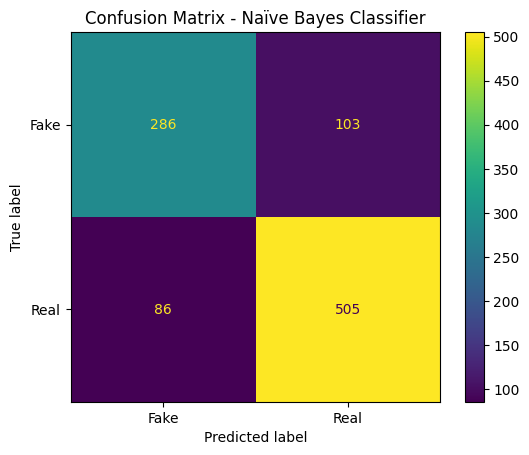

In [5]:
def train_naive_bayes(X_train, y_train, alpha=1.0):
    # Separate classes
    X_real = X_train[y_train == 1]
    X_fake = X_train[y_train == 0]
    
    # Priors
    p_real = X_real.shape[0] / X_train.shape[0]
    p_fake = X_fake.shape[0] / X_train.shape[0]
    
    # Word counts per class
    real_word_counts = np.asarray(X_real.sum(axis=0)).flatten()
    fake_word_counts = np.asarray(X_fake.sum(axis=0)).flatten()
    
    # Total word counts
    total_real_words = real_word_counts.sum()
    total_fake_words = fake_word_counts.sum()
    
    vocab_size = X_train.shape[1]
    
    # Likelihoods with Laplace smoothing
    p_word_given_real = (real_word_counts + alpha) / (total_real_words + alpha * vocab_size)
    p_word_given_fake = (fake_word_counts + alpha) / (total_fake_words + alpha * vocab_size)
    
    model = {
        "p_real": p_real,
        "p_fake": p_fake,
        "p_word_given_real": p_word_given_real,
        "p_word_given_fake": p_word_given_fake
    }
    return model


def predict_naive_bayes(model, X):
    log_p_real = np.log(model["p_real"])
    log_p_fake = np.log(model["p_fake"])
    log_p_word_given_real = np.log(model["p_word_given_real"])
    log_p_word_given_fake = np.log(model["p_word_given_fake"])
    
    predictions = []
    
    for i in range(X.shape[0]):
        x = np.asarray(X[i].toarray()).flatten()
        
        # Multinomial NB score
        score_real = log_p_real + np.sum(x * log_p_word_given_real)
        score_fake = log_p_fake + np.sum(x * log_p_word_given_fake)
        
        predictions.append(1 if score_real > score_fake else 0)
    
    return np.array(predictions)


def Naive_Bayes(X_train, y_train, X_test, y_test, alpha=1.0):
    model = train_naive_bayes(X_train, y_train, alpha=alpha)
    y_pred = predict_naive_bayes(model, X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return acc, cm, y_pred, model


#Run Classifier
accuracy, cm, y_pred, model = Naive_Bayes(X_train_f, y_train, X_test_f, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(cm)

# Plot consuion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot()
plt.title("Confusion Matrix - Naïve Bayes Classifier")
plt.show()

The Naïve Bayes classifier achieved a test accuracy of 80.71%, indicating that it correctly classifies most headlines.
The confusion matrix shows that 286 fake headlines and 505 real headlines were correctly classified, while 103 fake headlines were misclassified as real and 86 real headlines were misclassified as fake. The model performs slightly better on real headlines, likely due to the class imbalance, and tends to misclassify some fake headlines as real, which suggests overlap in word usage between the two classes.